# 01 — Neural Network From Scratch

### Why
Before using PyTorch, we need to *see* what a neural network actually is:
a stack of matrix multiplications, element-wise non-linearities, and the
chain rule applied backwards. Frameworks hide this — and that's fine for
productivity, but dangerous for debugging. If you don't know what
`loss.backward()` does, you can't tell when it does the wrong thing.

### What
We build a 2-layer MLP (input → hidden → output) on the classic
"two-moons" toy dataset. We implement:
  1. Forward pass          (numpy matmul + ReLU + softmax)
  2. Loss                  (cross-entropy)
  3. Backward pass         (manual gradients, chain rule)
  4. Parameter update      (vanilla SGD)

No autograd. No `nn.Module`. Just numpy and calculus.



##  Setup and reproducibility

### Why
Neural networks are stochastic: random weight init, random data splits,
random shuffling. If we don't fix the seed, the numbers you see and the
numbers a reviewer sees will differ — and "reproducible" is the first
thing a scholarship reviewer checks.

### What
Import numpy, set a global seed, and set a few numpy print options so
arrays are readable in the output cells.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

np.set_printoptions(precision=4 , suppress=True , linewidth=120)

## The dataset: two-moons

### Why
We need a dataset that:
  - is **non-linearly separable** (so a plain logistic regression fails,
    which motivates a hidden layer), and
  - is **tiny** (so we can run hundreds of epochs in seconds on CPU, and
    so we can actually visualize the decision boundary).

Two-moons is the canonical choice: two interleaved half-circles.

### What
Generate 1000 points, 2 features each, binary labels. Split into
train/test. Standardize features (neural nets are sensitive to input scale).

In [2]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   
X_test  = scaler.transform(X_test)  


print("X_train shape:", X_train.shape)   
print("X_test  shape:", X_test.shape)    
print("class balance (train):", np.bincount(y_train))

X_train shape: (800, 2)
X_test  shape: (200, 2)
class balance (train): [400 400]


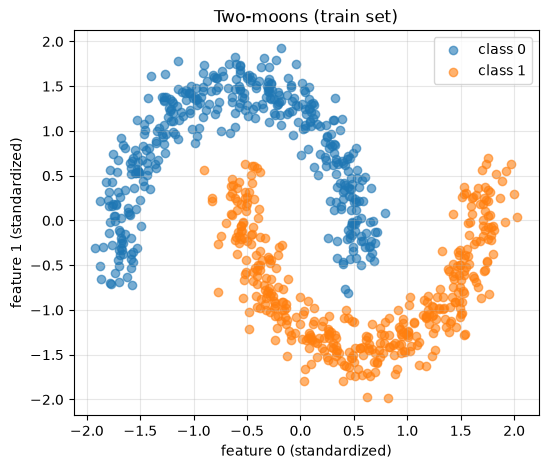

In [3]:
plt.figure(figsize=(6, 5))

# X_train[y_train == 0, 0]  → x-coord of class-0 points
# X_train[y_train == 0, 1]  → y-coord of class-0 points
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c="tab:blue", label="class 0", alpha=0.6)


plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c="tab:orange", label="class 1", alpha=0.6)

plt.title("Two-moons (train set)")
plt.xlabel("feature 0 (standardized)")
plt.ylabel("feature 1 (standardized)")
plt.legend()
plt.grid(alpha=0.3)   
plt.show()

##  The network architecture

We use the smallest non-trivial MLP:

    input (2)  →  hidden (16)  →  output (2)

- **2 inputs**  : our two features.
- **16 hidden** : enough capacity for two-moons; small enough to train fast.
- **2 outputs** : one score per class (logits). We then apply softmax.

### Why two layers, not one?
A single linear layer + softmax is exactly logistic regression — it can
only draw a straight decision boundary. Two-moons is not linearly
separable. The hidden layer + ReLU is what buys us non-linearity.

### Why ReLU and not sigmoid?
ReLU (`max(0, x)`) has a derivative that is either 0 or 1 — it doesn't
saturate for positive inputs, so gradients flow cleanly. Sigmoid saturates
at both ends and kills gradients. (In notebook 04 we'll see ReLU's own
failure mode: dead neurons.)

### What
Initialize weight matrices and biases with small random values.

In [4]:
INPUT_DIM  = 2
HIDDEN_DIM = 16
OUTPUT_DIM = 2

W1 = np.random.randn(INPUT_DIM,  HIDDEN_DIM) * np.sqrt(2.0 / INPUT_DIM)
b1 = np.zeros((1, HIDDEN_DIM))  
W2 = np.random.randn(HIDDEN_DIM, OUTPUT_DIM) * np.sqrt(2.0 / HIDDEN_DIM)
b2 = np.zeros((1, OUTPUT_DIM))

print("W1", W1.shape, "b1", b1.shape)
print("W2", W2.shape, "b2", b2.shape)

W1 (2, 16) b1 (1, 16)
W2 (16, 2) b2 (1, 2)


##  Forward pass, step by step

We compute, for a batch of N samples:

    z1 = X @ W1 + b1        # (N, 16)
    a1 = ReLU(z1)           # (N, 16)
    z2 = a1 @ W2 + b2       # (N, 2)  ← these are the "logits"
    p  = softmax(z2)        # (N, 2)  ← class probabilities

Then the loss is the negative log-likelihood of the true class:

    L = -mean( log p[i, y[i]] )

### Why softmax + NLL and not sigmoid + MSE?
Softmax + cross-entropy has a clean gradient: `p - onehot(y)`.
Sigmoid + MSE has a gradient that vanishes when the model is *confidently
wrong* — exactly when you need a strong gradient most.


In [5]:
def relu(z):
  return np.maximum(0.0, z)

def relu_grad(z):
  return (z > 0).astype(z.dtype)

def softmax(z):
  z = z - np.max(z, axis=1, keepdims=True)
  e = np.exp(z)
  return e / np.sum(e, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
  z1 = X @ W1 + b1
  a1 = relu(z1)               # (N, 16)
  z2 = a1 @ W2 + b2           # (N, 2)
  p  = softmax(z2)            # (N, 2)
  cache = (X, z1, a1, z2, p)
  return cache, p

### Cross-entropy loss

### Why
We need a scalar to minimize. For classification, cross-entropy (a.k.a.
negative log-likelihood) is the standard choice: it heavily penalizes
confident wrong predictions.

### What
Compute `-mean(log p[i, y[i]])`. Add a tiny epsilon inside the log to
avoid `log(0) = -inf`.

In [6]:
def cross_entropy(probs, y):
  N = probs.shape[0]
  correct_logprobs = -np.log(probs[np.arange(N), y] + 1e-12)  
  return correct_logprobs.mean()

##  Backward pass — the chain rule, made concrete



We want dL/dW1, dL/db1, dL/dW2, dL/db2.

Key fact that makes life easy: with softmax + cross-entropy, the gradient
of the loss w.r.t. the **logits** z2 is beautifully simple:

    dz2 = (p - onehot(y)) / N        # shape (N, 2)

Then walk backwards through each op:

    dW2 = a1.T @ dz2                 # (16, N) @ (N, 2) = (16, 2)
    db2 = sum(dz2, axis=0, keepdims=True)     # (1, 2)
    da1 = dz2 @ W2.T                 # (N, 2) @ (2, 16) = (N, 16)
    dz1 = da1 * relu_grad(z1)        # element-wise, (N, 16)
    dW1 = X.T @ dz1                  # (2, N) @ (N, 16) = (2, 16)
    db1 = sum(dz1, axis=0, keepdims=True)     # (1, 16)

### Why the /N?
Because our loss is a mean over the batch. When you backprop through a
mean, every gradient gets a 1/N factor. (If the loss were a sum, no 1/N.)

### What
Implement `backward(cache, y)` returning all four gradients.

In [7]:
def backward(cache, y):
    X, z1, a1, z2, p = cache
    N = X.shape[0]
    onehot = np.zeros_like(p)               
    onehot[np.arange(N), y] = 1.0
    dz2 = (p - onehot) / N                  
    dW2 = a1.T @ dz2                       
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = dz2 @ W2.T                        
    dz1 = da1 * relu_grad(z1)               
    dW1 = X.T @ dz1                         
    db1 = np.sum(dz1, axis=0, keepdims=True)  
    return dW1, db1, dW2, db2

## Gradient check
### Why
Manual gradients are exactly the kind of code that looks right and is
silently wrong (a transposed matrix, a missing /N). Before trusting the
training loop, verify the analytic gradient against a numerical one:

    numeric_grad ≈ (L(θ + ε) - L(θ - ε)) / (2ε)

If the relative error is < 1e-6, the analytic gradient is correct.

### What
Perturb each parameter by ±ε, compute the loss, compare.

In [8]:
def numeric_grad(param, eps, loss_fn):
    
    grad = np.zeros_like(param)
    it = np.nditer(param, flags=["multi_index"])
    while not it.finished:
        idx = it.multi_index
        original = param[idx]
        param[idx] = original + eps
        loss_plus = loss_fn()
        param[idx] = original - eps
        loss_minus = loss_fn()
        param[idx] = original                 # restore — crucial!
        grad[idx] = (loss_plus - loss_minus) / (2 * eps)
        it.iternext()
    return grad

eps = 1e-5

X_check = X_train[:8]
y_check = y_train[:8]

def loss_now():
    _, p = forward(X_check, W1, b1, W2, b2)
    return cross_entropy(p, y_check)

cache, _ = forward(X_check, W1, b1, W2, b2)
dW1, db1, dW2, db2 = backward(cache, y_check)

num_dW1 = numeric_grad(W1, eps, loss_now)
num_db1 = numeric_grad(b1, eps, loss_now)
num_dW2 = numeric_grad(W2, eps, loss_now)
num_db2 = numeric_grad(b2, eps, loss_now)

def rel_err(a, b):
    # Relative error, robust to the scale of the gradient.
    return np.max(np.abs(a - b) / (np.maximum(1e-8, np.abs(a) + np.abs(b))))

print("rel err dW1:", rel_err(dW1, num_dW1))
print("rel err db1:", rel_err(db1, num_db1))
print("rel err dW2:", rel_err(dW2, num_dW2))
print("rel err db2:", rel_err(db2, num_db2))


rel err dW1: 1.451234688993661e-09
rel err db1: 4.4526592602290445e-09
rel err dW2: 6.76385999491048e-11
rel err db2: 1.7341751075132693e-11


##  Training loop — vanilla SGD

### Why
Now that the gradients are verified, we can actually train. SGD is the
simplest optimizer: `θ ← θ - lr * dL/dθ`. Everything else (Momentum,
Adam, ...) is a refinement of this line.

### What
Full-batch gradient descent for 1000 epochs. Track the loss. Plot it.

In [9]:
lr = 0.5
epochs = 1000
loss_history = []

for epoch in range(epochs):
    
    cache, probs = forward(X_train, W1, b1, W2, b2)
    loss = cross_entropy(probs, y_train)
    loss_history.append(loss)

    
    dW1, db1, dW2, db2 = backward(cache, y_train)

    
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 100 == 0:
        print(f"epoch {epoch:4d}  loss {loss:.4f}")

print(f"epoch {epochs-1:4d}  loss {loss_history[-1]:.4f}")


epoch    0  loss 0.4710
epoch  100  loss 0.1605
epoch  200  loss 0.0525
epoch  300  loss 0.0267
epoch  400  loss 0.0178
epoch  500  loss 0.0133
epoch  600  loss 0.0106
epoch  700  loss 0.0088
epoch  800  loss 0.0076
epoch  900  loss 0.0066
epoch  999  loss 0.0059


### Loss curve

### Why
If the loss is not monotonically decreasing (allowing for tiny wobble),
something is wrong — LR too high, gradient bug, or data issue. Always plot.


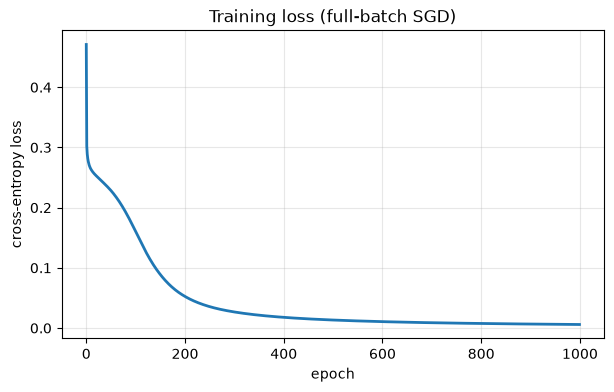

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, linewidth=2)
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Training loss (full-batch SGD)")
plt.grid(alpha=0.3)
plt.show()

##  Evaluation

### Why
Training loss going down doesn't mean the model *generalizes*. We need
accuracy on the held-out test set.

### What
Run forward on train and test, take argmax over class probabilities, and
compare to the true labels.

In [11]:
def accuracy(X , y):
  _, p = forward(X, W1 , b1 , W2 , b2)
  preds = np.argmax(p, axis=1)
  return (preds == y).mean()

train_acc = accuracy(X_train, y_train)
test_acc  = accuracy(X_test,  y_test)

print(f"train accuracy: {train_acc:.4f}")
print(f"test  accuracy: {test_acc:.4f}")

train accuracy: 1.0000
test  accuracy: 1.0000


## Visualize the decision boundary

### Why
Accuracy is one number. The decision boundary shows *what the model
learned* — you can literally see whether it captured the curved shape of
two-moons.

### What
Grid of points over the feature space, predict each, color by class.

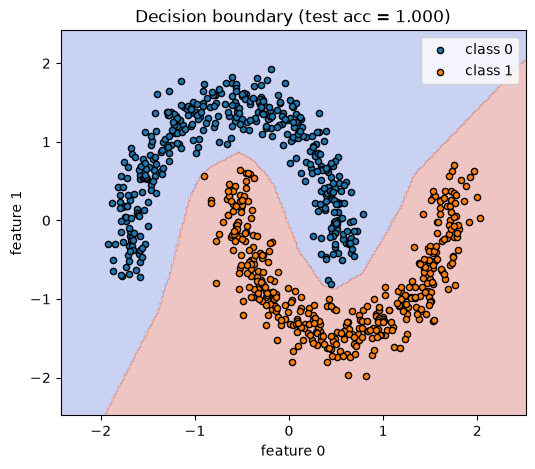

In [12]:
h = 0.02
x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid  = np.c_[xx.ravel(), yy.ravel()]
_, grid_probs = forward(grid, W1, b1, W2, b2)
grid_preds = np.argmax(grid_probs, axis=1).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap="coolwarm")

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c="tab:blue", edgecolor="k", s=20, label="class 0")
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c="tab:orange", edgecolor="k", s=20, label="class 1")

plt.title(f"Decision boundary (test acc = {test_acc:.3f})")
plt.xlabel("feature 0")
plt.ylabel("feature 1")
plt.legend()
plt.show()

##  What I learned / Open questions

### What I learned
- A neural network is: matmul → non-linearity → matmul → softmax, plus
  the chain rule running backwards.
- The softmax + cross-entropy gradient `(p - onehot)/N` is not a
  coincidence — it falls out of the math, and it's why this pairing is
  universal.
- Gradient checking is cheap insurance. Two lines of code saved me from
  shipping a transposed weight matrix.
- Full-batch SGD with a large LR is fine on tiny problems; it will not
  survive contact with MNIST. That's what notebook 02 + `DataLoader` fix.

### Open questions (to revisit)
- Why does He init (`sqrt(2/fan_in)`) specifically use 2, not 1? (Answer:
  it makes the variance of ReLU activations constant across layers —
  worth deriving properly in 04.)
- Where does softmax + CE gradient `p - onehot` come from? (Derive in 02.)
- How do I scale this to 60k images without a Python loop over samples?
  (Answer: batching + vectorization + DataLoader.)

### Bridge to notebook 02
Notebook 01 hard-codes:
  - the forward pass,
  - the backward pass,
  - the update rule.
Notebook 02 replaces all three with `torch.nn`, `loss.backward()`, and
`optim.SGD`, then proves the outputs match on the same data.